# Ejercicio Ridge, Lasso y ElasticNet
Para este ejercicio vas a trabajar con datos de ventas de una empresa que fabrica muebles en España. Esta empresa es una Pyme que demanda conocer de antemano qué ingresos va a tener cada mes, ya que necesita pedir un anticipio a su entidad financiera de cara a poder abastecerse de materia prima al comenzar el mes. Como desconoce cuánto tiene que pedir, tira al alza y acaba pagando muchos intereses. El objetivo es reducir estos gastos.

En las bases de datos de la empresa constan todos los gastos en publicidad y ventas, para cada uno de los meses desde su fundación (hace más de 15 años).

Dado que los presupuestos de marketing se cierran al principio de cada mes, la empresa necesita un modelo predictivo que le anticipe las ventas que conseguirá a final de mes en función de los gastos que realizará en marketing.

Para ello tendrás que utilizar tanto modelos de regresión normales, como regularizados.

1. Carga los datos y realiza un pequeño análisis exploratorio. Mira a ver cómo se relaciona las ventas con el resto de variables.
2. Crea varios modelos y modifica los hiperparámetros necesarios para mejorar el performance del modelo.
3. Interpreta los resultados. Traduce a una fórmula tu mejor modelo (escribir la fórmula simplemente). ¿Cuánto cambian las ventas si aumentamos la inversión en radio un punto más? ¿Y si aumentamos la inversión en TV o periódicos?

## Import libraries 

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Exploratory Data Analysis 

In [14]:
# Lectura datos, relación variables, mapas de correlación...
adver = pd.read_csv('data/Advertising.csv')

adver.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,0,230.1,37.8,69.2,22100.0
1,1,44.5,39.3,45.1,10400.0
2,2,17.2,45.9,69.3,9300.0
3,3,151.5,41.3,58.5,18500.0
4,4,180.8,10.8,58.4,12900.0


In [15]:
adver.describe().round(2)

,Unnamed: 0,TV,radio,newspaper,sales
count,200.00,200.00,200.00,200.00,200.00
mean,99.50,147.04,23.26,30.55,14022.50
std,57.88,85.85,14.85,21.78,5217.46
min,0.00,0.70,0.00,0.30,1600.00
25%,49.75,74.38,9.98,12.75,10375.00
50%,99.50,149.75,22.90,25.75,12900.00
75%,149.25,218.82,36.52,45.10,17400.00
max,199.00,296.40,49.60,114.00,27000.00


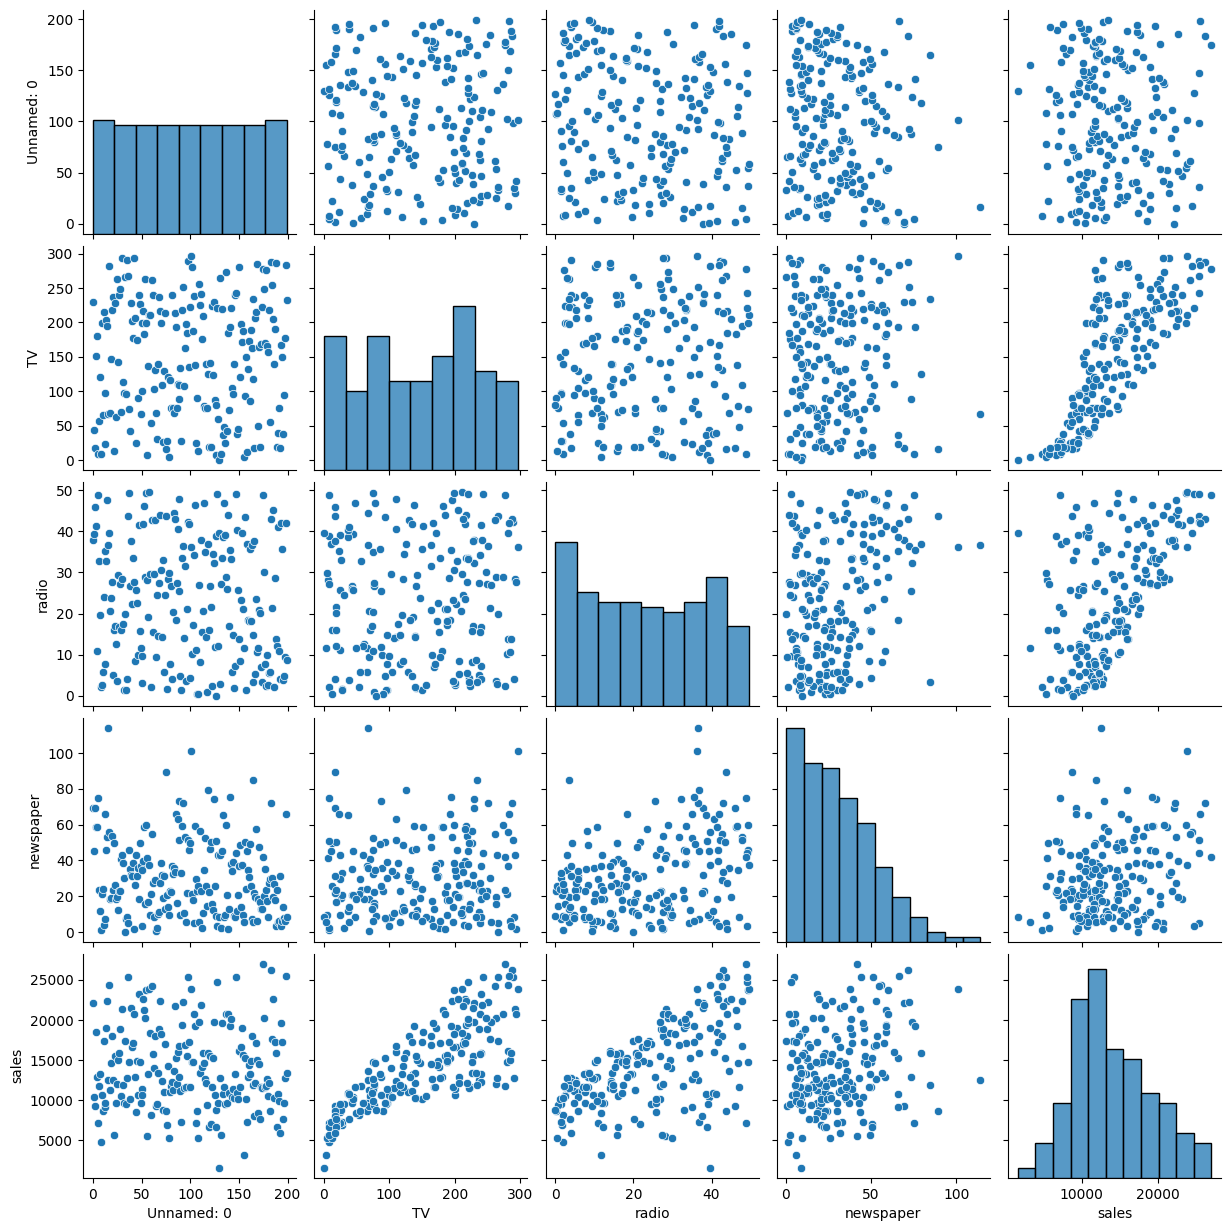

In [16]:
sns.pairplot(adver)

<Axes: >

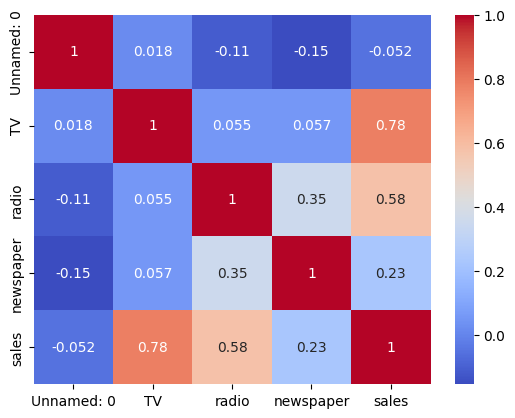

In [17]:
# sns.diverging_palette(145, 280, s=85, l=25, n=7)
sns.heatmap(adver.corr(), annot=True, cmap='coolwarm')

In [18]:
#TV es la variable que más correlacionada está con Sales, seguida de Radio y por último Newspaper. 
#Esto se puede ver en el mapa de calor y en el pairplot. Por lo tanto, TV es la variable que más influencia tiene en las ventas, seguida de Radio y por último Newspaper.

## Modelado

In [20]:
# Manipulación datasets, entrenamiento, evaluación, nuevas iteraciones... Prueba modelos sin y con regularización.

from sklearn.linear_model import ElasticNet

# 1. Preparación de los datos
# Eliminamos la columna 'Unnamed: 0' porque es solo un índice
X = adver[['TV', 'radio', 'newspaper']]
y = adver['sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()

lr.fit(X_train, y_train)    
y_pred = lr.predict(X_test)     
baseline_error = mean_absolute_error(y_test, y_pred)

print("Train MSE:", mean_squared_error(y_train, lr.predict(X_train)))
print("Test MSE:", mean_squared_error(y_test, lr.predict(X_test)))
print("Train R²:", lr.score(X_train, y_train)) 
print("Test R²:", lr.score(X_test, y_test))


Train MSE: 2705129.423081414
Test MSE: 3174097.3539761053
Train R²: 0.8957008271017817
Test R²: 0.899438024100912


In [26]:
lassoR = Lasso(alpha=1000)
lassoR.fit(X_train, y_train)

print("Train MSE:", mean_squared_error(y_train, lassoR.predict(X_train)))
print("Test MSE:", mean_squared_error(y_test, lassoR.predict(X_test)))
print("Train R²:", lassoR.score(X_train, y_train))
print("Test R²:", lassoR.score(X_test, y_test))

Train MSE: 2710410.341418215
Test MSE: 3143691.505367937
Train R²: 0.8954972156183637
Test R²: 0.9004013443377963


In [ ]:
# Separamos en train y test (80% entrenamiento, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalamos los datos (vital para Ridge, Lasso y ElasticNet)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# 2. Función auxiliar para entrenar y evaluar
def evaluar_modelo(model, X_train, X_test, y_train, y_test, nombre):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"--- {nombre} ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}\n")
    return model

# 3. Entrenamos los modelos
# Regresión Lineal estándar (la entrenamos sin escalar para poder interpretar los coeficientes de negocio fácilmente)
lr = evaluar_modelo(LinearRegression(), X_train, X_test, y_train, y_test, "Regresión Lineal (Sin Escalar)")

# Modelos Regularizados (Escalados)
ridge = evaluar_modelo(Ridge(alpha=1.0), X_train_scaled, X_test_scaled, y_train, y_test, "Regresión Ridge")
lasso = evaluar_modelo(Lasso(alpha=10.0), X_train_scaled, X_test_scaled, y_train, y_test, "Regresión Lasso")
elastic = evaluar_modelo(ElasticNet(alpha=0.1, l1_ratio=0.5), X_train_scaled, X_test_scaled, y_train, y_test, "ElasticNet")

--- Regresión Lineal (Sin Escalar) ---
RMSE: 1781.60
R2 Score: 0.8994

--- Regresión Ridge ---
RMSE: 1787.22
R2 Score: 0.8988

--- Regresión Lasso ---
RMSE: 1781.55
R2 Score: 0.8994

--- ElasticNet ---
RMSE: 1836.84
R2 Score: 0.8931



### Modelos Polinómicos

In [10]:
# 1. Creamos features polinómicas de grado 2 (incluye interacciones TV*Radio, etc.)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 2. Escalamos las nuevas variables
scaler_poly = StandardScaler()
X_train_poly_scaled = scaler_poly.fit_transform(X_train_poly)
X_test_poly_scaled = scaler_poly.transform(X_test_poly)

# 3. Entrenamos un Lasso sobre las variables polinómicas (Lasso descartará las combinaciones inútiles)
lasso_poly = evaluar_modelo(Lasso(alpha=10.0, max_iter=10000), 
                            X_train_poly_scaled, X_test_poly_scaled, 
                            y_train, y_test, "Lasso Polinómico (Grado 2)")

--- Lasso Polinómico (Grado 2) ---
RMSE: 609.18
R2 Score: 0.9882



## Resultados

In [11]:
# Interpreta, resume y destaca los puntos importantes de los resultados.
# Extraemos los coeficientes del modelo de Regresión Lineal (entrenado con datos sin escalar)
intercepto = lr.intercept_
coeficientes = lr.coef_

print("Fórmula del modelo de Regresión Lineal:")
print(f"Ventas = {intercepto:.2f} + ({coeficientes[0]:.2f} * TV) + ({coeficientes[1]:.2f} * Radio) + ({coeficientes[2]:.2f} * Newspaper)\n")

print("Impacto de aumentar 1 punto la inversión:")
print(f"TV: Aumenta las ventas en {coeficientes[0]:.2f}")
print(f"Radio: Aumenta las ventas en {coeficientes[1]:.2f}")
print(f"Periódico: Cambia las ventas en {coeficientes[2]:.2f}")

Fórmula del modelo de Regresión Lineal:
Ventas = 2979.07 + (44.73 * TV) + (189.20 * Radio) + (2.76 * Newspaper)

Impacto de aumentar 1 punto la inversión:
TV: Aumenta las ventas en 44.73
Radio: Aumenta las ventas en 189.20
Periódico: Cambia las ventas en 2.76


In [12]:
# Utiliza todas las celdas que necesites...